# Corpus Extraction and Exploratory Data Analysis
## CAS NLP 2025/26, University of Bern  — Final Project 

This notebook documents the text extraction pipeline and provides 
exploratory data analysis of the Jugend und Medien corpus used as 
knowledge base for the cross-lingual RAG system.
 
**Data source**: www.jugendundmedien.ch / www.jeunesetmedias.ch / www.giovaniemedia.ch

## 1. Environment Setup

Import required libraries and set working directory to project root.

In [ ]:
import fitz
import os
import pathlib
import pandas as pd
import matplotlib.pyplot as plt

os.chdir('/Users/Olga 1/Documents/01_AD_ASTRA/0102_LANGUAGES/CAS_NLP_2025/final_project')

# Reload file lists after any renaming
brochures = sorted(pathlib.Path("data/used/brochures").glob("*.txt"))
flyers = sorted(pathlib.Path("data/used/flyers").glob("*.txt"))

print(f"PyMuPDF version: {fitz.__version__}")
print(f"Working directory: {os.getcwd()}")
print(f"Brochures: {len(brochures)} — Flyers: {len(flyers)}")

PyMuPDF version: 1.27.2.3
Working directory: /Users/Olga 1/Documents/01_AD_ASTRA/0102_LANGUAGES/CAS_NLP_2025/final_project
Brochures: 15 — Flyers: 40


## 2. Corpus Overview

Collect all extracted TXT files from brochures and flyers directories.

**Brochures** (FR/DE/IT only): thematic expert documents averaging 40-52 pages, 
constituting the primary knowledge base. Five topics: general recommendations, 
school context, social/therapeutic institutions, peer education, 
online radicalisation prevention.

**Flyers**: short documents available in multiple languages, 
categorised into four sub-types detailed in section 3.

In [ ]:
brochures = sorted(pathlib.Path("data/used/brochures").glob("*.txt"))
flyers = sorted(pathlib.Path("data/used/flyers").glob("*.txt"))

print(f"Brochures: {len(brochures)} files")
print(f"Flyers: {len(flyers)} files")
print(f"Total: {len(brochures) + len(flyers)} files")

Brochures: 15 files
Flyers: 40 files
Total: 55 files


## 3. File Inventory by Type and Language

Flyers are categorised into four sub-types based on their naming convention:
- **Standard flyers**: age-specific recommendations (0-7, 6-13, 12-18), all languages
- **Easy Language flyers**: simplified register versions (FR/DE/IT only)
- **Extended flyers**: consolidated all-age documents with additional explanations (SQ/RU/TI/ES)
- **Image rights flyers**: specific guidance on children's image rights (FR/DE/IT only)

In [ ]:
standard = [f for f in flyers if '/jm-f-2' in str(f) and 'easy' not in str(f) and 'ext' not in str(f) and 'image-rights' not in str(f)]
easy = [f for f in flyers if 'easy' in str(f)]
ext = [f for f in flyers if 'f-ext' in str(f)]
image_rights = [f for f in flyers if 'image-rights' in str(f)]

print(f"Standard flyers: {len(standard)}")
print(f"Easy Language flyers: {len(easy)}")
print(f"Extended flyers: {len(ext)}")
print(f"Image rights flyers: {len(image_rights)}")
print(f"Total: {len(standard)+len(easy)+len(ext)+len(image_rights)}")

Standard flyers: 21
Easy Language flyers: 9
Extended flyers: 4
Image rights flyers: 6
Total: 40


## 4. Language Distribution

Parse language codes from filenames (suffix after final underscore, e.g. `_fr`).
Counts files per language, broken down by document type (brochures vs flyers).

In [ ]:
def get_lang(path):
    return path.stem.split("_")[-1]

records = (
    [{"file": f.name, "lang": get_lang(f), "type": "brochure"} for f in brochures] +
    [{"file": f.name, "lang": get_lang(f), "type": "flyer"} for f in flyers]
)

df = pd.DataFrame(records)
lang_dist = df.groupby(["lang", "type"]).size().unstack(fill_value=0)
lang_dist["total"] = lang_dist.sum(axis=1)
lang_dist = lang_dist.sort_values("total", ascending=False)

print(lang_dist.to_string())

type  brochure  flyer  total
lang                        
de           5      8     13
fr           5      8     13
it           5      8     13
es           0      4      4
ru           0      4      4
sq           0      4      4
ti           0      4      4


## 5. Document Length Statistics

Word count and character count per file, grouped by document type.
Used to calibrate chunking strategy and identify outliers 
(very short files may indicate extraction issues).

In [ ]:
def count_words(path):
    text = path.read_text(encoding="utf-8", errors="ignore")
    return len(text.split()), len(text)

rows = []
for f in brochures:
    wc, cc = count_words(f)
    rows.append({"file": f.name, "type": "brochure", "lang": get_lang(f), "words": wc, "chars": cc})
for f in flyers:
    wc, cc = count_words(f)
    rows.append({"file": f.name, "type": "flyer",    "lang": get_lang(f), "words": wc, "chars": cc})

df_len = pd.DataFrame(rows)

print("=== Stats by type ===")
print(df_len.groupby("type")[["words","chars"]].agg(["mean","median","min","max"]).round(0))

print("\n=== Potential outliers (< 300 words) ===")
outliers = df_len[df_len["words"] < 300][["file","type","lang","words"]]
print(outliers.to_string(index=False) if not outliers.empty else "None")

=== Stats by type ===
            words                           chars                         
             mean   median   min    max      mean    median    min     max
type                                                                      
brochure  14624.0  14886.0  9431  19099  102376.0  114334.0  73666  126886
flyer      1252.0    874.0   196   6423    8202.0    5860.0   1381   40873

=== Potential outliers (< 300 words) ===
                                 file  type lang  words
jm-f-2021-image-rights-parents_de.txt flyer   de    219
jm-f-2021-image-rights-parents_fr.txt flyer   fr    263
jm-f-2021-image-rights-parents_it.txt flyer   it    219
  jm-f-2021-image-rights-youth_de.txt flyer   de    198
  jm-f-2021-image-rights-youth_fr.txt flyer   fr    239
  jm-f-2021-image-rights-youth_it.txt flyer   it    196


## 6. Language Distribution — Visualisation

Bar chart showing file count per language, broken down by document type.

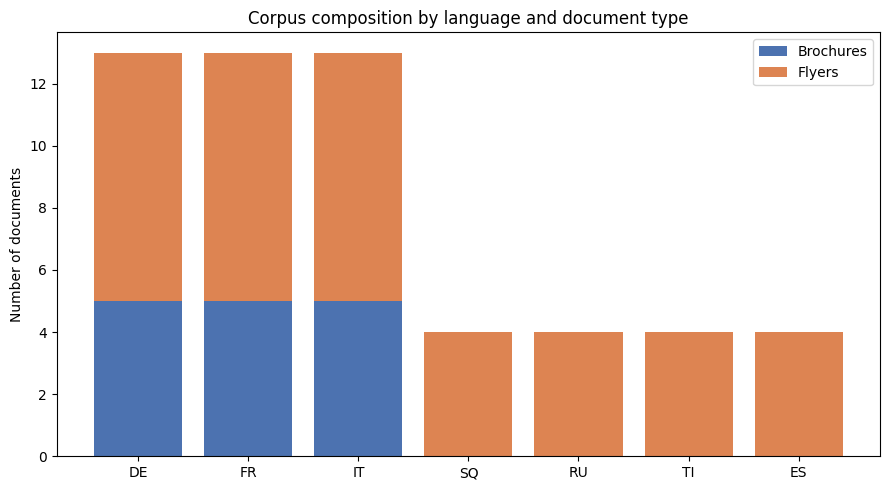

Figure saved.


In [6]:
import matplotlib.pyplot as plt

# corpus composition by language and document type
languages = ["DE", "FR", "IT", "SQ", "RU", "TI", "ES"]
brochures = [5, 5, 5, 0, 0, 0, 0]
flyers_full = [8, 8, 8, 4, 4, 4, 4]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(languages, brochures, label="Brochures", color="#4C72B0")
ax.bar(languages, flyers_full, bottom=brochures, label="Flyers", color="#DD8452")

ax.set_ylabel("Number of documents")
ax.set_title("Corpus composition by language and document type")
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/nb01_corpus_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved.")